In [1]:
from pp_functions import *
from shapely.ops import unary_union
from affine import Affine
import numpy as np

import xarray as xr
import rioxarray
from datetime import datetime
from rasterio.transform import from_origin
from rasterio.enums import Resampling


import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cmcrameri.cm as cmc
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1 import ImageGrid
from matplotlib.lines import Line2D

In [7]:
# Define Basin, Model Run, Year
name = 'BUDD'
model = 'composite'
year = 2020
starting_value = 0
utm_epsg = 'EPSG:32611'
# utm_epsg = 'EPSG:26913'

# Define filepaths and directories
# mask filepaths
BS = f'/home/etboud/projects/data/basins/{name}/{name}_4326.geojson'
basin_buff_fn = f'/home/etboud/projects/data/masks/{name}_mask_buffered.tif'
basin_fn = f'/home/etboud/projects/data/masks/{name}_mask.tif'
rgi = '/home/etboud/projects/data/RGI/02_rgi60_WesternCanadaUS/02_rgi60_WesternCanadaUS.shp'
wbd = '/home/etboud/projects/data/masks/NHDWaterbody.shp'
can = f'/home/etboud/projects/data/masks/4b_15img_ndvi_30_85_{name}_notclipped.tif'
# raw PS images
ps_raw = f'/data0/images/planet/emma/planet/{name}/'
# Processed PS SCA
ps_sca_dir = f'/data0/images/planet/emma/planet/raw_snow_maps/{name}/{model}/'


# Read in masks
basin = gpd.read_file(BS).to_crs(utm_epsg)
basin_buff_mask = rxr.open_rasterio(basin_buff_fn)
rgi_mask = gpd.read_file(rgi).to_crs(utm_epsg)
wbd_mask = gpd.read_file(wbd).to_crs(utm_epsg)
invalid_area = unary_union(rgi_mask.geometry.values.tolist() + wbd_mask.geometry.values.tolist())
ndvi_mask = rxr.open_rasterio(can)
ndvi_mask.values = np.where(ndvi_mask.values>0, 0, 1)

# Get directories
ps_raw_subdir = sorted([d for d in glob.glob(ps_raw + str(year) + '*') if os.path.isdir(d)])
ps_sca_tif = glob.glob(ps_sca_dir + f'*{year}*.tif')


In [3]:
# Load the reference GeoTIFF with ideal output projection and resolution
with rio.open(f'/home/etboud/projects/data/masks/{name}_mask.tif') as ref:
    ref_crs = ref.crs
    ref_transform = ref.transform
    ref_width = ref.width
    ref_height = ref.height

### stacking aso

In [ ]:
corr_files = pd.read_csv('/home/etboud/projects/snow_mapping/COPP_corresponding_files.csv') #/home/etboud/projects/snow_mapping/corresponding_files_all.csv
corr_files
# corr_yr_files = corr_files[(corr_files['model_run']=='V5')&(corr_files['model_file'].split('/')[-3]==name)]
# Apply split to each 'model_file' entry and filter based on 'model_run' and the extracted name
corr_yr_files = corr_files[
    (corr_files['model_run'] == 'V5') & 
    (corr_files['model_file'].apply(lambda x: x.split('/')[-3] == name))
]
corr_yr_files.drop_duplicates(subset='aso_date', keep='last',inplace=True)
# corr_yr_files = corr_files[corr_files['aso_date'].astype(str).str[:4]== str(year)]

aso_list = []
date_list = []
for index, row in corr_yr_files.iterrows():
    print(row['aso_file'])
    aso_data = rxr.open_rasterio(row['aso_file'],masked=True)
    aso_data.values = np.where(np.isnan(aso_data.values), 0, aso_data.values)
    aso_data = aso_data.rio.clip(basin.geometry, drop=False)
    aso_data = aso_data.rio.clip(rgi_mask.geometry, invert=True)
    aso_data = aso_data.rio.clip(wbd_mask.geometry, invert=True)
    # plot aso_data
    aso_data.plot()
    date = row['aso_date']
    date_list.append(date)
    aso_list.append(aso_data.squeeze().values)
    
# Create a stacked data array for ASO snow cover
stacked_data = np.stack(aso_list, axis=0).astype(float)
# Make an array of the dates
dates = np.array(date_list)
dates = pd.to_datetime(dates, format='%Y-%m-%d')
# Step 2: Ensure dates are properly formatted and used as time coordinates
# No need to stack dates as floats; they will be used directly as time coordinates

# Step 3: Generate real-world coordinate arrays from ref_transform
x_coords = np.arange(ref_width) * ref_transform.a + ref_transform.c
y_coords = np.arange(ref_height) * ref_transform.e + ref_transform.f
# if ref_transform.e < 0:
#     y_coords = y_coords[::-1]

# Step 4: Build the DataArray with real coordinates
xr_data = xr.DataArray(
    stacked_data,
    dims=['time', 'y', 'x'],
    coords={'time': dates, 'y': y_coords, 'x': x_coords}
)

# Step 5: Assign CRS and transform directly
xr_data = xr_data.rio.write_crs(ref_crs)
xr_data = xr_data.rio.write_transform(ref_transform)
xr_data.name = "data"
# Step 6: Save to NetCDF
xr_data.to_netcdf(f'/home/etboud/projects/data/stacks/{name}_aso_projected.nc', format='NETCDF4')

### Stacking model outputs

In [4]:
valid_area = unary_union(basin.geometry.values)
final_geometry = valid_area.difference(invalid_area)
# Step 1: Build your data stack (clipped_data should be the same size as BUDD_mask)
dates_list = []
data_list = []

for file in sorted(ps_sca_tif):
    date = np.datetime64(datetime.strptime(os.path.basename(file).split('_')[0], '%Y%m%d'))
    dates_list.append(date)

    data = rxr.open_rasterio(file, drop=True, chunks = True, masked=True).squeeze('band', drop=True)
    data = data.fillna(0)
    data = data.rio.clip([final_geometry], basin.crs)
    # Optional: assert shape matches reference
    assert data.shape == (ref_height, ref_width), f"Shape mismatch: {data.shape}"

    data_list.append(data.values)  # get raw values for stacking

# Step 2: Stack the data
stacked_data = np.stack(data_list, axis=0).astype(float)

# Step 3: Generate real-world coordinate arrays from ref_transform
x_coords = np.arange(ref_width) * ref_transform.a + ref_transform.c
y_coords = np.arange(ref_height) * ref_transform.e + ref_transform.f
# if ref_transform.e < 0:
#     y_coords = y_coords[::-1]

# Step 4: Build the DataArray with real coordinates
xr_data = xr.DataArray(
    stacked_data,
    dims=['time', 'y', 'x'],
    coords={'time': dates_list, 'y': y_coords, 'x': x_coords}
)

# Step 5: Assign CRS and transform directly
xr_data = xr_data.rio.write_crs(ref_crs)
xr_data = xr_data.rio.write_transform(ref_transform)
xr_data.name = "data"
# Step 6: Save to NetCDF
xr_data.to_netcdf(f'/home/etboud/projects/data/stacks/{name}_{model}_{year}_projected.nc', format='NETCDF4')

### Temporal post-processing

In [8]:
# Looping through snow maps and applying temporal post processing
files = sorted(glob.glob(ps_sca_dir + f'*{year}*SCA.tif'))[starting_value:] 

# Initialize
ref_date = datetime(year - 1, 10, 1).date()
dates_list = []
data_list = []

# Loop through the good planet scenes
for fCount, file in enumerate(files):
    date = np.datetime64(datetime.strptime(os.path.basename(file).split('_')[0], '%Y%m%d'))
    dates_list.append(date)
    data = rxr.open_rasterio(file, drop=True, chunks = True, masked=True).squeeze('band', drop=True)
    data= data.fillna(0)
    data = data.rio.clip([invalid_area], invert=True) #testing
    data_list.append(data.squeeze())

stacked_data = np.stack(data_list, axis=0).astype(float)
nodata_ref = stacked_data.copy()
stacked_data = fill_nodata(stacked_data)
# Performing temporal QAQC
resulting_data = qaqc_temp(stacked_data = stacked_data, 
                                            chm_mask =ndvi_mask, 
                                            basin_mask = basin_buff_mask[0], 
                                            buff_raster_fn = basin_buff_fn,
                                            small_raster_fn = basin_fn)

# projecting the post processed arrays
assert resulting_data.shape[-2:] == (ref_height, ref_width), "Data shape doesn't match GeoTIFF shape."
x_coords = np.arange(ref_width) * ref_transform.a + ref_transform.c
y_coords = np.arange(ref_height) * ref_transform.e + ref_transform.f
xr_data = xr.DataArray(
    resulting_data,
    dims=['time', 'y', 'x'],
    coords={'time': dates_list, 'y': y_coords, 'x': x_coords}
)
xr_data = xr_data.rio.write_crs(ref_crs)
xr_data = xr_data.rio.write_transform(ref_transform)
xr_data.name = "data"
# Saving stacked data to netcdf
xr_data.to_netcdf(f'/home/etboud/projects/data/stacks/{name}_{model}T_{year}_QAQC_temporal1.nc',format='NETCDF4')

Buffered Raster Bounds: BoundingBox(left=288159.0, bottom=4190019.0, right=291105.0, top=4195104.0)
Smaller Raster Bounds: BoundingBox(left=288261.0, bottom=4190121.0, right=291003.0, top=4195002.0)
final data checks ...


## Spatial post-processing

In [8]:
# looping through snow maps and applying spatial and temporal post processing
files = sorted(glob.glob(ps_sca_dir + f'*{year}*SCA.tif'))[starting_value:]

# Loop through threshold and radius combinations
thresholds = [.3]
radii = [3]
# Initialize
ref_date = datetime(year - 1, 10, 1).date()

dates_list = []
data_list = []
x_coords = np.arange(ref_width) * ref_transform.a + ref_transform.c
y_coords = np.arange(ref_height) * ref_transform.e + ref_transform.f

# Loop through the good planet scenes
for fCount, file in enumerate(files):
    date = np.datetime64(datetime.strptime(os.path.basename(file).split('_')[0], '%Y%m%d'))
    dates_list.append(date)
    data = rxr.open_rasterio(file, drop=True, chunks = True, masked=True,crs = ref_crs).squeeze('band', drop=True)
    if data.rio.crs != ref_crs:
        data = data.rio.reproject(ref_crs)
    data= data.fillna(0)
    data = data.rio.clip([invalid_area], invert=True) #testing
    data_list.append(data.values)
    
for threshold_percent in thresholds:
    for radius in radii:

        stacked_data = np.stack(data_list, axis=0).astype(float)
        nodata_ref = stacked_data.copy()
        # stacked_data = fill_nodata(stacked_data)
        # Perform spatial and temporal QA/QC on stacked data with the canopy mask
        resulting_data = qaqc_spatial(stacked_data = stacked_data, 
                                            chm_mask =ndvi_mask, 
                                            radius = radius, 
                                            threshold_percent = threshold_percent, 
                                            basin_mask = basin_buff_mask[0], 
                                            buff_raster_fn = basin_buff_fn,
                                            small_raster_fn = basin_fn)
        print(resulting_data.shape)


        xr_data = xr.DataArray(
            resulting_data,
            dims=['time', 'y', 'x'],
            coords={'time': dates_list, 'y': y_coords, 'x': x_coords}
        )
        xr_data = xr_data.rio.write_crs(ref_crs)
        xr_data = xr_data.rio.write_transform(ref_transform)
        xr_data.name = "data"
        percent = round(threshold_percent*100)
        # Save the resulting data to a NetCDF file
        xr_data.to_netcdf(f'/home/etboud/projects/data/stacks/{name}_{model}S_{year}_{radius}_{percent}.nc', format='NETCDF4')

        print(f"Processed and saved file for threshold: {threshold_percent}, radius: {radius}")

Buffered Raster Bounds: BoundingBox(left=290466.0, bottom=4195185.0, right=298614.0, top=4202463.0)
Smaller Raster Bounds: BoundingBox(left=290562.0, bottom=4195284.0, right=298512.0, top=4202367.0)
final data checks ...
(84, 2361, 2650)
Processed and saved file for threshold: 0.3, radius: 3


In [ ]:
# looping through snow maps and applying spatial and temporal post processing
files = sorted(glob.glob(ps_sca_dir + f'*{year}*SCA.tif'))[starting_value:]

# Loop through threshold and radius combinations
thresholds = [.9]
radii = [1,3,5]
# Initialize
ref_date = datetime(year - 1, 10, 1).date()
dates_list = []
data_list = []

for threshold_percent in thresholds:
    for radius in radii:
        dates_list = []
        data_list = []
        # Loop through the good planet scenes
        for fCount, file in enumerate(files):
            date = np.datetime64(datetime.strptime(os.path.basename(file).split('_')[0], '%Y%m%d'))
            dates_list.append(date)
            data = rxr.open_rasterio(file, drop=True, chunks = True, masked=True,crs = ref_crs).squeeze('band', drop=True)
            if data.rio.crs != ref_crs:
                data = data.rio.reproject(ref_crs)
            data= data.fillna(0)
            data = data.rio.clip([invalid_area], invert=True) #testing
            data_list.append(data.values)


        stacked_data = np.stack(data_list, axis=0).astype(float)
        nodata_ref = stacked_data.copy()
        # stacked_data = fill_nodata(stacked_data)
        # Perform spatial and temporal QA/QC on stacked data with the canopy mask
        resulting_data = qaqc_spatial(stacked_data = stacked_data, 
                                            chm_mask =ndvi_mask, 
                                            radius = radius, 
                                            threshold_percent = threshold_percent, 
                                            basin_mask = basin_buff_mask[0], 
                                            buff_raster_fn = basin_buff_fn,
                                            small_raster_fn = basin_fn)
        print(resulting_data.shape)

        assert resulting_data.shape[-2:] == (ref_height, ref_width), "Data shape doesn't match GeoTIFF shape."
        x_coords = np.arange(ref_width) * ref_transform.a + ref_transform.c
        y_coords = np.arange(ref_height) * ref_transform.e + ref_transform.f


        xr_data = xr.DataArray(
            resulting_data,
            dims=['time', 'y', 'x'],
            coords={'time': dates_list, 'y': y_coords, 'x': x_coords}
        )
        xr_data = xr_data.rio.write_crs(ref_crs)
        xr_data = xr_data.rio.write_transform(ref_transform)
        xr_data.name = "data"
        percent = round(threshold_percent*100)
        # Save the resulting data to a NetCDF file
        xr_data.to_netcdf(f'/home/etboud/projects/data/stacks/{name}_{model}S_{year}_{radius}_{percent}_NDVI_QAQC.nc', format='NETCDF4')

        print(f"Processed and saved file for threshold: {threshold_percent}, radius: {radius}")

Buffered Raster Bounds: BoundingBox(left=288159.0, bottom=4190019.0, right=291105.0, top=4195104.0)
Smaller Raster Bounds: BoundingBox(left=288261.0, bottom=4190121.0, right=291003.0, top=4195002.0)
final data checks ...
(111, 1627, 914)
Processed and saved file for threshold: 0.9, radius: 1
Buffered Raster Bounds: BoundingBox(left=288159.0, bottom=4190019.0, right=291105.0, top=4195104.0)
Smaller Raster Bounds: BoundingBox(left=288261.0, bottom=4190121.0, right=291003.0, top=4195002.0)
final data checks ...
(111, 1627, 914)
Processed and saved file for threshold: 0.9, radius: 3
Buffered Raster Bounds: BoundingBox(left=288159.0, bottom=4190019.0, right=291105.0, top=4195104.0)
Smaller Raster Bounds: BoundingBox(left=288261.0, bottom=4190121.0, right=291003.0, top=4195002.0)
final data checks ...
(111, 1627, 914)
Processed and saved file for threshold: 0.9, radius: 5


### Spatial and Temporal post-processing

In [9]:
# looping through snow maps and applying spatial and temporal post processing
files = sorted(glob.glob(ps_sca_dir + f'*{year}*SCA.tif'))[starting_value:]

# Loop through threshold and radius combinations
thresholds = [.3]
radii = [3]
# Initialize
ref_date = datetime(year - 1, 10, 1).date()

dates_list = []
data_list = []
x_coords = np.arange(ref_width) * ref_transform.a + ref_transform.c
y_coords = np.arange(ref_height) * ref_transform.e + ref_transform.f

# Loop through the good planet scenes
for fCount, file in enumerate(files):
    date = np.datetime64(datetime.strptime(os.path.basename(file).split('_')[0], '%Y%m%d'))
    dates_list.append(date)
    data = rxr.open_rasterio(file, drop=True, chunks = True, masked=True,crs = ref_crs).squeeze('band', drop=True)
    if data.rio.crs != ref_crs:
        data = data.rio.reproject(ref_crs)
    data= data.fillna(0)
    data = data.rio.clip([invalid_area], invert=True) #testing
    data_list.append(data.values)
    
for threshold_percent in thresholds:
    for radius in radii:

        stacked_data = np.stack(data_list, axis=0).astype(float)
        nodata_ref = stacked_data.copy()
        stacked_data = fill_nodata(stacked_data)
        # Perform spatial and temporal QA/QC on stacked data with the canopy mask
        resulting_data = qaqc_spatial_temp(stacked_data = stacked_data, 
                                            chm_mask =ndvi_mask, 
                                            radius = radius, 
                                            threshold_percent = threshold_percent, 
                                            basin_mask = basin_buff_mask[0], 
                                            buff_raster_fn = basin_buff_fn,
                                            small_raster_fn = basin_fn)
        print(resulting_data.shape)


        xr_data = xr.DataArray(
            resulting_data,
            dims=['time', 'y', 'x'],
            coords={'time': dates_list, 'y': y_coords, 'x': x_coords}
        )
        xr_data = xr_data.rio.write_crs(ref_crs)
        xr_data = xr_data.rio.write_transform(ref_transform)
        xr_data.name = "data"
        percent = round(threshold_percent*100)
        # Save the resulting data to a NetCDF file
        xr_data.to_netcdf(f'/home/etboud/projects/data/stacks/sep/{name}_{model}ST5F_{year}_{radius}_{percent}.nc', format='NETCDF4')

        print(f"Processed and saved file for threshold: {threshold_percent}, radius: {radius}")

Buffered Raster Bounds: BoundingBox(left=288159.0, bottom=4190019.0, right=291105.0, top=4195104.0)
Smaller Raster Bounds: BoundingBox(left=288261.0, bottom=4190121.0, right=291003.0, top=4195002.0)
(85, 1627, 914)
Processed and saved file for threshold: 0.3, radius: 3


In [ ]:
# looping through snow maps and applying spatial and temporal post processing
files = sorted(glob.glob(ps_sca_dir + f'*{year}*SCA.tif'))[starting_value:]

# Loop through threshold and radius combinations
thresholds = [.35,.45,.55,.65,.75,.85,.95]
radii = [3]
# Initialize
ref_date = datetime(year - 1, 10, 1).date()
dates_list = []
data_list = []

for threshold_percent in thresholds:
    for radius in radii:
        dates_list = []
        data_list = []
        # Loop through the good planet scenes
        for fCount, file in enumerate(files):
            date = np.datetime64(datetime.strptime(os.path.basename(file).split('_')[0], '%Y%m%d'))
            dates_list.append(date)
            data = rxr.open_rasterio(file, drop=True, chunks = True, masked=True,crs = ref_crs).squeeze('band', drop=True)
            if data.rio.crs != ref_crs:
                data = data.rio.reproject(ref_crs)
            data= data.fillna(0)
            data = data.rio.clip([invalid_area], invert=True) #testing
            data_list.append(data.values)


        stacked_data = np.stack(data_list, axis=0).astype(float)
        nodata_ref = stacked_data.copy()
        stacked_data = fill_nodata(stacked_data)
        # Perform spatial and temporal QA/QC on stacked data with the canopy mask
        resulting_data = qaqc_spatial_temp(stacked_data = stacked_data, 
                                            chm_mask =ndvi_mask, 
                                            radius = radius, 
                                            threshold_percent = threshold_percent, 
                                            basin_mask = basin_buff_mask[0], 
                                            buff_raster_fn = basin_buff_fn,
                                            small_raster_fn = basin_fn)
        print(resulting_data.shape)

        assert resulting_data.shape[-2:] == (ref_height, ref_width), "Data shape doesn't match GeoTIFF shape."
        x_coords = np.arange(ref_width) * ref_transform.a + ref_transform.c
        y_coords = np.arange(ref_height) * ref_transform.e + ref_transform.f


        xr_data = xr.DataArray(
            resulting_data,
            dims=['time', 'y', 'x'],
            coords={'time': dates_list, 'y': y_coords, 'x': x_coords}
        )
        xr_data = xr_data.rio.write_crs(ref_crs)
        xr_data = xr_data.rio.write_transform(ref_transform)
        xr_data.name = "data"
        percent = round(threshold_percent*100)
        # Save the resulting data to a NetCDF file
        xr_data.to_netcdf(f'/home/etboud/projects/data/stacks/{name}_{model}ST_{year}_{radius}_{percent}_NDVI_QAQC_smoothing.nc', format='NETCDF4')

        print(f"Processed and saved file for threshold: {threshold_percent}, radius: {radius}")

### CHECK: Plot

In [3]:
def create_fsca_df(dataset):
    sca_df = []
    for t in range(len(dataset.time)):
        slice = dataset['data'].isel(time=t)
        fsca = (np.nansum(slice) / np.count_nonzero(~np.isnan(slice)))*100
        if fsca> 100:
            fsca = 100
        sca_df.append(fsca)    
    #create dataframe with fsca_list and corresponding dates
    dates = pd.to_datetime(dataset.time.values)
    df = pd.DataFrame({'date': dates, 'fsca': sca_df})
    return df

In [9]:
# output = xr.open_dataset(f'/home/etboud/projects/data/stacks/BUDD_{model}_{year}_projected.nc')
# output_df = create_fsca_df(output)
# temporal = xr.open_dataset(f'/home/etboud/projects/data/stacks/BUDD_{model}PP_{year}_QAQC_temporal.nc')
# temp_df = create_fsca_df(temporal)
# spatial = xr.open_dataset(f'/home/etboud/projects/data/stacks/BUDD_{model}PP_{year}_3_50_NDVI_QAQC.nc')
# spat_df = create_fsca_df(spatial)
# test = xr.open_dataset(f'/home/etboud/projects/data/stacks/BUDD_M1_2022_projected.nc')
# test_df = create_fsca_df(test)
# test_pp = xr.open_dataset(f'/home/etboud/projects/data/stacks/BUDD_M1PP_2022_3_50_NDVI_QAQC_smoothing.nc')
# test_pp_df = create_fsca_df(test)
modis_df = create_fsca_df(modis_sca_ds)

In [11]:
aso = xr.open_dataset(f'/home/etboud/projects/data/stacks/extra/{name}_aso_projected.nc')
aso_df = create_fsca_df(aso)
aso_df = aso_df[(aso_df['date'] > '2022-01-01') & (aso_df['date'] < '2023-01-01')].sort_values(by='date')

(-5.0, 105.0)

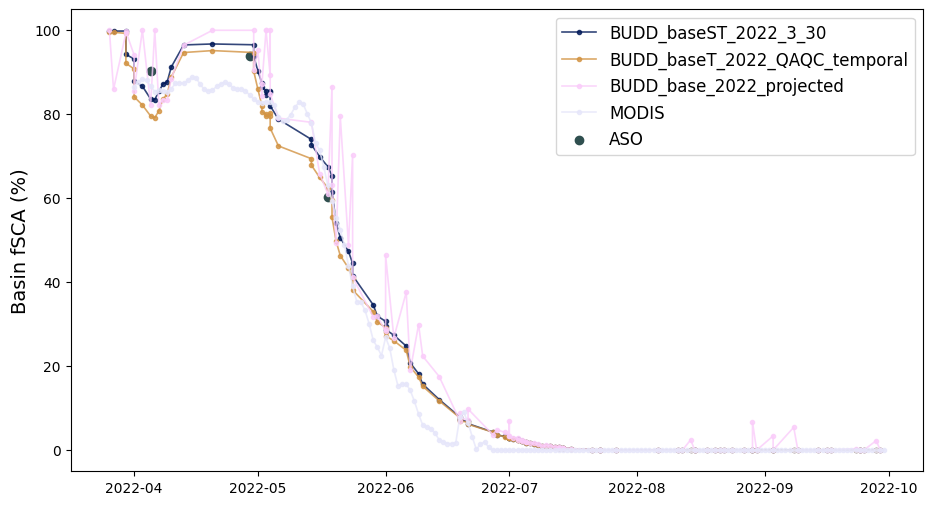

In [23]:
import cmcrameri.cm as cmc
name = 'base'
year = '2022'
files = sorted(glob.glob(f'/home/etboud/projects/data/stacks/sep/*{name}*{year}*.nc'))
n_colors = len(files)
colors = [tuple(cmc.batlow(i / (n_colors - 1))) for i in range(n_colors)]
fig, ax = plt.subplots(figsize=(11, 6))
for i, file in enumerate(files):
    if 'baseS_' not in file:
        
        temp = xr.open_dataset(file)
        temp_df = create_fsca_df(temp)
        #plot on the same plot
        m_name = os.path.basename(file).split('.')[0]
        ax.plot(temp_df['date'], temp_df['fsca'], label = m_name, color = colors[i], linewidth=1.2,marker='o', markersize=3, alpha=0.8)
    # ax.scatter(temp_df['date'], temp_df['fsca'], color = 'teal', s = 3)
    
ax.plot(modis_df['date'], modis_df['fsca'], label = 'MODIS', color='lavender', linewidth=1.2, marker='o', markersize=3, alpha=0.8)
ax.scatter(aso_df['date'], aso_df['fsca'], label = 'ASO', color='darkslategrey')
ax.legend(loc='upper right', fontsize=12)
ax.set_ylabel('Basin fSCA (%)', fontsize=14)
ax.set_ylim(-5, 105)



In [20]:
corr_files = pd.read_csv('/home/etboud/projects/snow_mapping/Emma/corresponding_files_all.csv') # have not tested yet
corr_fn = corr_files[corr_files['aso_date'].astype(str).str[:4]== str(year)]
# Filering down what we want to look at 
corr_fn = corr_fn[corr_fn['model_run']=='V5']
corr_fn = corr_fn[corr_fn['raw_file'].str.contains(name)]
corr_fn = corr_fn.drop(columns= ['model_file', 'model_run', 'raw_file','aso_file'])
#corr_fn.drop(index=25, inplace=True)
corr_fn = corr_fn.sort_values(by=corr_fn.columns.tolist())
corr_fn

,aso_date,ps_date
19,2022-04-05,2022-04-03
25,2022-04-05,2022-04-07
20,2022-04-29,2022-04-30
21,2022-05-18,2022-05-18


### Reprojecting MODIS